In [1]:
# ============================================
# CELL 1: LOAD DATASET & EKSPLORASI AWAL
# ============================================

# Import library
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')  # biar output tidak berantakan

# Ambil dataset dari Google Drive
# Data ini berisi informasi kondisi mesin produksi untuk prediktif maintenance
url = "https://drive.google.com/uc?id=1UdPnGjX6xoB6jcwA1cXO8rG-KjDaq9IR"
df = pd.read_csv(url)

print("="*50)
print("DATASET AWAL")
print("="*50)

# Lima baris pertama buat lihat struktur kolom
print("\n📋 5 Data Pertama:")
print(df.head())

# Ukuran dataset
print(f"\n📊 Shape Dataset: {df.shape[0]} baris x {df.shape[1]} kolom")

# Sebaran jenis kerusakan di data
print("\n🔍 Distribusi Failure Type:")
print(df['Failure Type'].value_counts())
print("="*50)

DATASET AWAL

📋 5 Data Pertama:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  

📊 Shape Dataset: 10000 baris x 10 kolom

🔍 Distribusi Failur

In [2]:
# ============================================
# CELL 2: FEATURE ENGINEERING - MEMBUAT PREDIKSI_WAKTU
# ============================================

# Fungsi untuk mengestimasi sisa umur mesin (Remaining Useful Life/RUL)
# Nilai yang dihasilkan akan digunakan sebagai fitur dalam model prediktif
def create_prediction_time(row):
    """
    Menghitung estimasi waktu tersisa sebelum mesin mengalami kerusakan.

    Parameter:
    - row: satu baris data dari dataset

    Faktor yang diperhitungkan:
    1. Tool wear - keausan alat, semakin tinggi semakin memperpendek sisa waktu
    2. Temperature - suhu udara dan proses, kenaikan suhu mempercepat kerusakan
    3. Rotational speed - kecepatan putar, deviasi dari nilai ideal meningkatkan risiko
    4. Torque - torsi, beban berat memperpendek umur mesin
    5. Failure type - menentukan tingkat urgensi pada mesin yang sudah terdeteksi rusak

    Returns:
    - float: estimasi sisa waktu dalam hari (rentang 1-30 hari)
    """

    # Asumsi awal: umur maksimal mesin normal adalah 30 hari
    base_time = 30

    # Faktor keausan alat
    # Nilai wear berkisar 0-200+ menit, semakin tinggi semakin mengurangi sisa waktu
    tool_wear_factor = max(0, 1 - (row['Tool wear [min]'] / 200))

    # Faktor suhu udara
    # Suhu normal sekitar 295K, kenaikan di atas nilai tersebut mempercepat kerusakan
    temp_factor = max(0, 1 - ((row['Air temperature [K]'] - 295) / 20))

    # Faktor suhu proses
    # Suhu normal sekitar 305K, pola yang sama dengan suhu udara
    process_temp_factor = max(0, 1 - ((row['Process temperature [K]'] - 305) / 15))

    # Faktor kecepatan putar
    # RPM ideal di angka 1500, penyimpangan dari nilai ini meningkatkan risiko
    rpm_factor = max(0, 1 - (abs(row['Rotational speed [rpm]'] - 1500) / 1000))

    # Faktor torsi
    # Ambang batas aman di 60Nm, semakin tinggi torsi semakin berisiko
    torque_factor = max(0, 1 - (row['Torque [Nm]'] / 60))

    # Kombinasi seluruh faktor dengan pembobotan
    # Tool wear mendapat bobot tertinggi karena dianggap paling berpengaruh
    combined_factor = (tool_wear_factor * 0.3 +
                      temp_factor * 0.2 +
                      process_temp_factor * 0.2 +
                      rpm_factor * 0.15 +
                      torque_factor * 0.15)

    # Penyesuaian untuk mesin yang sudah terdeteksi rusak
    # Failure multiplier berfungsi memperpendek sisa waktu sesuai jenis kerusakan
    if row['Target'] == 1:
        failure_type = row['Failure Type']
        if failure_type == 'Power Failure':
            failure_multiplier = 0.1
        elif failure_type == 'Overstrain Failure':
            failure_multiplier = 0.15
        elif failure_type == 'Heat Dissipation Failure':
            failure_multiplier = 0.2
        elif failure_type == 'Tool Wear Failure':
            failure_multiplier = 0.25
        else:
            failure_multiplier = 0.3
    else:
        failure_multiplier = 1.0

    # Perhitungan akhir
    prediction_time = base_time * combined_factor * failure_multiplier

    # Penambahan noise untuk memberikan variasi pada data
    prediction_time += np.random.normal(0, 2)

    # Pembatasan rentang nilai agar tetap realistis
    prediction_time = max(1, min(30, prediction_time))

    return round(prediction_time, 1)


# Penerapan fungsi ke seluruh baris pada dataframe
df['Prediksi_Waktu'] = df.apply(create_prediction_time, axis=1)


# Verifikasi hasil
print("="*50)
print("DATASET DENGAN FITUR PREDIKSI_WAKTU")
print("="*50)
print("\n📋 Contoh data (Target=1 = rusak, Target=0 = normal):")
print(df[['Target', 'Failure Type', 'Prediksi_Waktu']].head(10))
print("="*50)

DATASET DENGAN FITUR PREDIKSI_WAKTU

📋 Contoh data (Target=1 = rusak, Target=0 = normal):
   Target Failure Type  Prediksi_Waktu
0       0   No Failure            22.9
1       0   No Failure            24.5
2       0   No Failure            22.4
3       0   No Failure            23.0
4       0   No Failure            22.9
5       0   No Failure            23.7
6       0   No Failure            22.8
7       0   No Failure            22.4
8       0   No Failure            24.4
9       0   No Failure            23.6


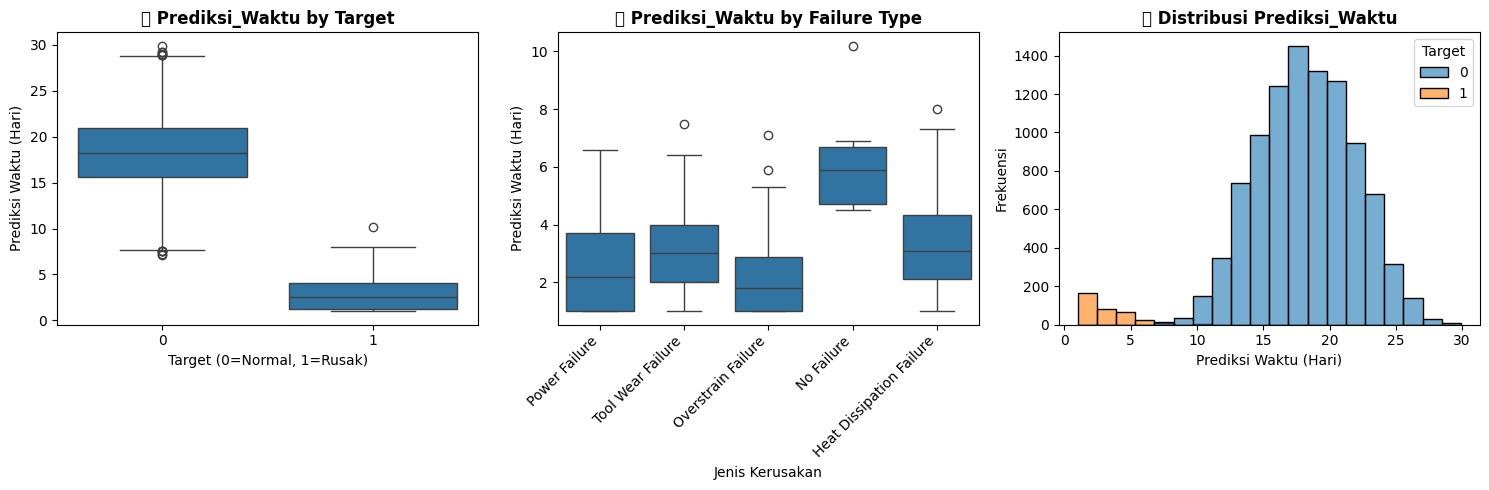

ANALISIS STATISTIK PREDIKSI_WAKTU

📋 Statistik berdasarkan Target:
   (0 = Mesin Normal, 1 = Mesin Rusak)
--------------------------------------------------
         count       mean       std  min    25%   50%   75%   max
Target                                                           
0       9661.0  18.241776  3.634728  7.1  15.60  18.2  20.9  29.9
1        339.0   2.884366  1.698491  1.0   1.25   2.6   4.1  10.2
--------------------------------------------------

📋 Statistik berdasarkan Jenis Kerusakan:
--------------------------------------------------
                           count       mean       std  min     25%   50%  \
Failure Type                                                               
Heat Dissipation Failure   112.0   3.302679  1.596305  1.0   2.100   3.1   
No Failure                9652.0  18.234760  3.651183  4.5  15.600  18.2   
Overstrain Failure          78.0   2.291026  1.504296  1.0   1.000   1.8   
Power Failure               95.0   2.478947  1.555286  

In [3]:
# ============================================
# CELL 3: VISUALISASI & ANALISIS DISTRIBUSI PREDIKSI_WAKTU
# ============================================

# Membuat figure dengan 3 subplot dalam satu baris
plt.figure(figsize=(15, 5))

# Subplot 1: Boxplot Prediksi_Waktu berdasarkan Target
# Digunakan untuk melihat perbedaan sebaran sisa waktu antara mesin normal dan rusak
plt.subplot(1, 3, 1)
sns.boxplot(x='Target', y='Prediksi_Waktu', data=df)
plt.title('📊 Prediksi_Waktu by Target', fontsize=12, fontweight='bold')
plt.xlabel('Target (0=Normal, 1=Rusak)')
plt.ylabel('Prediksi Waktu (Hari)')

# Subplot 2: Boxplot Prediksi_Waktu berdasarkan Failure Type
# Memvisualisasikan perbedaan sisa waktu antar jenis kerusakan
plt.subplot(1, 3, 2)
failure_df = df[df['Target'] == 1]
sns.boxplot(x='Failure Type', y='Prediksi_Waktu', data=failure_df)
plt.title('📊 Prediksi_Waktu by Failure Type', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Jenis Kerusakan')
plt.ylabel('Prediksi Waktu (Hari)')

# Subplot 3: Histogram distribusi Prediksi_Waktu
# Menampilkan sebaran data secara keseluruhan dengan membandingkan dua kondisi
plt.subplot(1, 3, 3)
sns.histplot(data=df, x='Prediksi_Waktu', hue='Target', bins=20, alpha=0.6)
plt.title('📊 Distribusi Prediksi_Waktu', fontsize=12, fontweight='bold')
plt.xlabel('Prediksi Waktu (Hari)')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()


# Analisis statistik deskriptif untuk memahami karakteristik data
print("="*60)
print("ANALISIS STATISTIK PREDIKSI_WAKTU")
print("="*60)

# Statistik berdasarkan Target
# Memberikan gambaran perbedaan antara mesin normal dan mesin rusak
print("\n📋 Statistik berdasarkan Target:")
print("   (0 = Mesin Normal, 1 = Mesin Rusak)")
print("-" * 50)
print(df.groupby('Target')['Prediksi_Waktu'].describe())
print("-" * 50)

# Statistik berdasarkan Failure Type
# Menunjukkan karakteristik sisa waktu untuk setiap jenis kerusakan
print("\n📋 Statistik berdasarkan Jenis Kerusakan:")
print("-" * 50)
print(df.groupby('Failure Type')['Prediksi_Waktu'].describe())
print("-" * 50)
print("="*60)

In [4]:
# ============================================
# CELL 4: PERSIAPAN DATASET UNTUK MODELING
# ============================================

# Encoding variabel kategorikal
# Data kategorikal perlu diubah menjadi numerik agar dapat diproses oleh model machine learning
le_type = LabelEncoder()
le_failure = LabelEncoder()

df['Type_encoded'] = le_type.fit_transform(df['Type'])
df['Failure_Type_encoded'] = le_failure.fit_transform(df['Failure Type'])

print("✅ Encoding selesai!")
print(f"   - Type mapping: {dict(zip(le_type.classes_, le_type.transform(le_type.classes_)))}")
print(f"   - Failure Type mapping: {dict(zip(le_failure.classes_, le_failure.transform(le_failure.classes_)))}")


# Menentukan kolom yang akan dijadikan fitur
# Fitur-fitur ini dipilih berdasarkan korelasinya terhadap target
feature_columns = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Type_encoded'
]

print(f"\n✅ {len(feature_columns)} fitur telah ditentukan untuk modeling.")


# Persiapan dataset untuk dua jenis tugas
# 1. Klasifikasi   : memprediksi apakah mesin rusak atau tidak (binary) dan jenis kerusakan (multi-class)
# 2. Regresi       : memprediksi sisa waktu sebelum kerusakan terjadi

# Dataset untuk klasifikasi
X_classification = df[feature_columns]
y_classification_target = df['Target']
y_classification_failure = df['Failure_Type_encoded']

# Dataset untuk regresi
X_regression = df[feature_columns]
y_regression = df['Prediksi_Waktu']


# Pengecekan dimensi dataset untuk memastikan kesesuaian
print("\n" + "="*60)
print("📊 DIMENSI DATASET UNTUK MODELING")
print("="*60)
print(f"✅ Features shape       : {X_classification.shape}")
print(f"✅ Target (Klasifikasi) : {y_classification_target.shape}")
print(f"✅ Failure Type (Multi) : {y_classification_failure.shape}")
print(f"✅ Prediksi Waktu (Regresi) : {y_regression.shape}")
print("="*60)


# Menyimpan dataset hasil enrichment
# File ini akan digunakan pada tahap modeling berikutnya
df.to_csv('predictive_maintenance_with_time_prediction.csv', index=False)

print("\n💾 Dataset baru telah disimpan:")
print(f"   📁 Nama file: 'predictive_maintenance_with_time_prediction.csv'")
print(f"   📊 Ukuran: {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"   ✨ Fitur baru: 'Prediksi_Waktu', 'Type_encoded', 'Failure_Type_encoded'")
print("="*60)

✅ Encoding selesai!
   - Type mapping: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}
   - Failure Type mapping: {'Heat Dissipation Failure': np.int64(0), 'No Failure': np.int64(1), 'Overstrain Failure': np.int64(2), 'Power Failure': np.int64(3), 'Random Failures': np.int64(4), 'Tool Wear Failure': np.int64(5)}

✅ 6 fitur telah ditentukan untuk modeling.

📊 DIMENSI DATASET UNTUK MODELING
✅ Features shape       : (10000, 6)
✅ Target (Klasifikasi) : (10000,)
✅ Failure Type (Multi) : (10000,)
✅ Prediksi Waktu (Regresi) : (10000,)

💾 Dataset baru telah disimpan:
   📁 Nama file: 'predictive_maintenance_with_time_prediction.csv'
   📊 Ukuran: 10000 baris x 13 kolom
   ✨ Fitur baru: 'Prediksi_Waktu', 'Type_encoded', 'Failure_Type_encoded'


In [5]:
# ============================================
# CELL 5: DEMONSTRASI OUTPUT & REKOMENDASI
# ============================================

# Menampilkan simulasi notifikasi untuk mesin yang terdeteksi bermasalah
# Memberikan gambaran bagaimana sistem akan merespon ketika mendeteksi potensi kerusakan
print("="*60)
print("🚨 CONTOH OUTPUT SISTEM PREDIKTIF MAINTENANCE")
print("="*60)
print("\n📋 Menampilkan 20 data mesin yang terdeteksi berisiko rusak:")

# Mengambil sampel data mesin dengan status rusak
sample_failures = df[df['Target'] == 1].head(20)

# Daftar rekomendasi perbaikan untuk setiap jenis kerusakan
recommendations = {
    'Power Failure': "⚠️  Disarankan melakukan pengecekan beban listrik dan kondisi power supply.",
    'Overstrain Failure': "⚠️  Disarankan mengurangi beban kerja dan memeriksa komponen mekanik.",
    'Heat Dissipation Failure': "⚠️  Disarankan membersihkan sistem pendingin dan memeriksa kipas.",
    'Tool Wear Failure': "⚠️  Disarankan mengganti tool dan melakukan kalibrasi.",
    'No Failure': "✅ Tidak diperlukan maintenance segera."
}

# Iterasi untuk menampilkan setiap mesin bermasalah beserta rekomendasinya
for idx, row in sample_failures.iterrows():
    failure_type = row['Failure Type']
    prediction_time = row['Prediksi_Waktu']
    machine_id = row['Product ID']

    print(f"\n🚨 Mesin {machine_id} kemungkinan mengalami {failure_type}.")
    print(f"   ⏰ Estimasi waktu kerusakan: {prediction_time} hari.")
    print(f"   💡 {recommendations.get(failure_type, 'Perlu diagnosis lebih lanjut.')}")
    print("-" * 50)


# Menampilkan contoh mesin normal sebagai perbandingan
# Memberikan gambaran output untuk skenario kondisi mesin sehat
print("\n" + "="*60)
print("✅ CONTOH MESIN DALAM KONDISI NORMAL")
print("="*60)

sample_normal = df[df['Target'] == 0].head(2)

for idx, row in sample_normal.iterrows():
    machine_id = row['Product ID']
    prediction_time = row['Prediksi_Waktu']
    print(f"\n✅ Mesin {machine_id} dalam kondisi normal.")
    print(f"   ⏰ Estimasi waktu hingga maintenance terjadwal: {prediction_time} hari.")
    print(f"   💡 {recommendations['No Failure']}")
    print("-" * 50)

print("="*60)

🚨 CONTOH OUTPUT SISTEM PREDIKTIF MAINTENANCE

📋 Menampilkan 20 data mesin yang terdeteksi berisiko rusak:

🚨 Mesin L47230 kemungkinan mengalami Power Failure.
   ⏰ Estimasi waktu kerusakan: 5.6 hari.
   💡 ⚠️  Disarankan melakukan pengecekan beban listrik dan kondisi power supply.
--------------------------------------------------

🚨 Mesin L47249 kemungkinan mengalami Power Failure.
   ⏰ Estimasi waktu kerusakan: 5.7 hari.
   💡 ⚠️  Disarankan melakukan pengecekan beban listrik dan kondisi power supply.
--------------------------------------------------

🚨 Mesin L47257 kemungkinan mengalami Tool Wear Failure.
   ⏰ Estimasi waktu kerusakan: 3.3 hari.
   💡 ⚠️  Disarankan mengganti tool dan melakukan kalibrasi.
--------------------------------------------------

🚨 Mesin L47340 kemungkinan mengalami Overstrain Failure.
   ⏰ Estimasi waktu kerusakan: 1.0 hari.
   💡 ⚠️  Disarankan mengurangi beban kerja dan memeriksa komponen mekanik.
--------------------------------------------------

🚨 Mesin